# PTB-XL Arrhythmia Classification with 1-D CNN

This notebook implements a **1-D Convolutional Neural Network** for multi-label ECG arrhythmia classification on the [PTB-XL dataset](https://physionet.org/content/ptb-xl/1.0.3/).  
We target the five **diagnostic superclasses**: `NORM`, `MI`, `STTC`, `CD`, `HYP`.

**Pipeline overview**
1. Data loading & label extraction  
2. Preprocessing & stratified splitting (per official folds)  
3. PyTorch Dataset / DataLoader  
4. 1-D CNN architecture  
5. Training loop with mixed-precision & LR scheduling  
6. Evaluation (AUC-ROC, F1, confusion matrices)  
7. Inference helper  

> **Note:** The notebook uses the **100 Hz** (`records100/`) recordings to keep memory and compute requirements modest. Switch `SAMPLING_RATE = 500` and `filename_hr` to use 500 Hz signals.

## 0 — Environment & Imports

In [1]:
# Install dependencies (uncomment if running fresh)
%pip install wfdb 

   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   -------------------- ------------------- 0.5/1.0 MB 4.2 MB/s eta 0:00:01
   ---------------------------------------- 1.0/1.0 MB 3.5 MB/s eta 0:00:00

   ---------------------------------------- 2/2 [wfdb]

Note: you may need to restart the kernel to use updated packages.


In [1]:
import os, ast, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm

import wfdb

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast

from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report,
    multilabel_confusion_matrix, average_precision_score
)
from sklearn.preprocessing import StandardScaler

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


## 1 — Configuration

In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────
DATA_DIR      = 'archive/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1'      
DB_CSV        = os.path.join(DATA_DIR, 'ptbxl_database.csv')
SCP_CSV       = os.path.join(DATA_DIR, 'scp_statements.csv')

# ── Signal settings ────────────────────────────────────────────────────────
SAMPLING_RATE = 100          # 100 or 500
N_LEADS       = 12           # standard 12-lead ECG
SEQ_LEN       = 1000         # samples per record (100 Hz × 10 s)

# ── Label settings ─────────────────────────────────────────────────────────
SUPERCLASSES  = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
N_CLASSES     = len(SUPERCLASSES)

# ── Training ───────────────────────────────────────────────────────────────
BATCH_SIZE    = 64
EPOCHS        = 5
LR            = 1e-3
WEIGHT_DECAY  = 1e-4
PATIENCE      = 10           # early-stopping patience

# ── Checkpoint ─────────────────────────────────────────────────────────────
CKPT_PATH     = 'best_1dcnn.pt'

## 2 — Data Loading & Label Extraction

In [3]:
# ── Load metadata ──────────────────────────────────────────────────────────
df = pd.read_csv(DB_CSV, index_col='ecg_id')
df.scp_codes = df.scp_codes.apply(ast.literal_eval)

# ── Load SCP statements and keep only diagnostic ones ─────────────────────
scp = pd.read_csv(SCP_CSV, index_col=0)
scp_diag = scp[scp.diagnostic == 1].copy()

print(f'Total records : {len(df):,}')
print(f'Diagnostic SCP codes: {len(scp_diag)}')
df.head(3)

Total records : 21,837
Diagnostic SCP codes: 44


,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr


In [4]:
def map_to_superclass(scp_codes: dict) -> list:
    """Return list of superclass labels for a record's scp_codes dict."""
    labels = set()
    for code, likelihood in scp_codes.items():
        if code in scp_diag.index:
            sc = scp_diag.loc[code, 'diagnostic_class']
            if isinstance(sc, str) and sc in SUPERCLASSES:
                labels.add(sc)
    return list(labels)

df['superclass'] = df.scp_codes.apply(map_to_superclass)

# Drop records with no diagnostic superclass
df = df[df.superclass.map(len) > 0].copy()
print(f'Records with at least one superclass label: {len(df):,}')

# Build binary label matrix
for sc in SUPERCLASSES:
    df[sc] = df.superclass.apply(lambda x: int(sc in x))

print('\nLabel distribution:')
print(df[SUPERCLASSES].sum().rename('count').to_frame())

Records with at least one superclass label: 21,430

Label distribution:
      count
NORM   9528
MI     5486
STTC   5250
CD     4907
HYP    2655


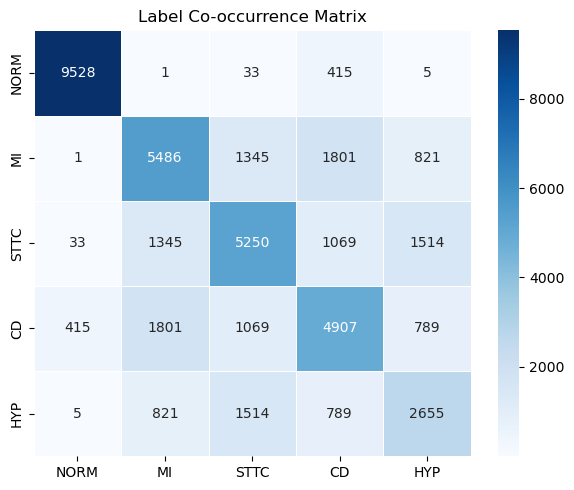

In [5]:
# ── Visualise label co-occurrence ──────────────────────────────────────────
co = df[SUPERCLASSES].T.dot(df[SUPERCLASSES])
mask = np.triu(np.ones_like(co, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(co, annot=True, fmt='d', cmap='Blues', linewidths=.5, ax=ax)
ax.set_title('Label Co-occurrence Matrix')
plt.tight_layout()
plt.show()

## 3 — Train / Validation / Test Split

We follow the **official PTB-XL protocol**: folds 1–8 → train, fold 9 → validation, fold 10 → test.

In [6]:
train_df = df[df.strat_fold <= 8].copy()
val_df   = df[df.strat_fold == 9].copy()
test_df  = df[df.strat_fold == 10].copy()

print(f'Train: {len(train_df):,}  |  Val: {len(val_df):,}  |  Test: {len(test_df):,}')

# ── Compute class weights for loss balancing ───────────────────────────────
pos = train_df[SUPERCLASSES].sum().values          # positives per class
neg = len(train_df) - pos                          # negatives per class
pos_weight = torch.tensor(neg / pos, dtype=torch.float32).to(DEVICE)
print('\nPos weights (neg/pos per class):')
for sc, w in zip(SUPERCLASSES, pos_weight.cpu()):
    print(f'  {sc}: {w:.2f}')

Train: 17,111  |  Val: 2,156  |  Test: 2,163

Pos weights (neg/pos per class):
  NORM: 1.25
  MI: 2.90
  STTC: 3.08
  CD: 3.37
  HYP: 7.07


## 4 — Dataset & DataLoader

In [7]:
class PTBXLDataset(Dataset):
    """Loads raw WFDB signals on-the-fly and returns (signal, label) pairs.

    Args:
        dataframe : subset of ptbxl_database.csv
        data_dir  : root directory of the dataset
        sampling_rate : 100 or 500
        scaler    : fitted sklearn StandardScaler (or None)
        augment   : whether to apply training augmentations
    """

    def __init__(self, dataframe, data_dir, sampling_rate=100,
                 scaler=None, augment=False):
        self.df      = dataframe.reset_index(drop=False)
        self.root    = data_dir
        self.sr      = sampling_rate
        self.scaler  = scaler
        self.augment = augment
        self.fn_col  = 'filename_lr' if sampling_rate == 100 else 'filename_hr'

    def __len__(self):
        return len(self.df)

    def _load_signal(self, idx):
        row  = self.df.iloc[idx]
        path = os.path.join(self.root, row[self.fn_col])
        sig, _ = wfdb.rdsamp(path)
        return sig.astype(np.float32)   # (T, 12)

    # ── Augmentations ────────────────────────────────────────────────────────
    @staticmethod
    def _add_gaussian_noise(sig, std=0.01):
        return sig + np.random.randn(*sig.shape).astype(np.float32) * std

    @staticmethod
    def _random_scale(sig, low=0.9, high=1.1):
        return sig * np.random.uniform(low, high)

    @staticmethod
    def _random_shift(sig, max_shift=50):
        shift = np.random.randint(-max_shift, max_shift)
        return np.roll(sig, shift, axis=0)

    def __getitem__(self, idx):
        sig = self._load_signal(idx)          # (T, 12)

        # ── Normalise ─────────────────────────────────────────────────────
        if self.scaler is not None:
            sig = self.scaler.transform(sig)
        else:
            sig = (sig - sig.mean(axis=0)) / (sig.std(axis=0) + 1e-8)

        # ── Augmentations (training only) ─────────────────────────────────
        if self.augment:
            if np.random.rand() < 0.5:
                sig = self._add_gaussian_noise(sig)
            if np.random.rand() < 0.5:
                sig = self._random_scale(sig)
            if np.random.rand() < 0.3:
                sig = self._random_shift(sig)

        # (T, 12) → (12, T)  for Conv1d  (channels first)
        sig = sig.T
        sig = torch.tensor(sig, dtype=torch.float32)

        row    = self.df.iloc[idx]
        labels = torch.tensor(row[SUPERCLASSES].values.astype(np.float32))
        return sig, labels

In [8]:
USE_GLOBAL_SCALER = False
scaler = None

if USE_GLOBAL_SCALER:
    print('Fitting global scaler on a 2 000-record sample …')
    sample_df = train_df.sample(2000, random_state=SEED)
    fn_col    = 'filename_lr' if SAMPLING_RATE == 100 else 'filename_hr'
    signals   = []
    for _, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
        sig, _ = wfdb.rdsamp(os.path.join(DATA_DIR, row[fn_col]))
        signals.append(sig)
    all_sig = np.concatenate(signals, axis=0)
    scaler  = StandardScaler().fit(all_sig)
    print('Scaler fitted.')

# ── Build datasets ─────────────────────────────────────────────────────────
train_ds = PTBXLDataset(train_df, DATA_DIR, SAMPLING_RATE, scaler, augment=True)
val_ds   = PTBXLDataset(val_df,   DATA_DIR, SAMPLING_RATE, scaler, augment=False)
test_ds  = PTBXLDataset(test_df,  DATA_DIR, SAMPLING_RATE, scaler, augment=False)

# ── num_workers=0 avoids wfdb fork-safety deadlock ────────────────────────
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False)

print(f'Batches — train: {len(train_loader)} | val: {len(val_loader)} | test: {len(test_loader)}')

sig_b, lbl_b = next(iter(train_loader))
print(f'Signal batch: {sig_b.shape}   Labels batch: {lbl_b.shape}')

Batches — train: 268 | val: 34 | test: 34
Signal batch: torch.Size([64, 12, 1000])   Labels batch: torch.Size([64, 5])


## 5 — Visualise a Sample ECG

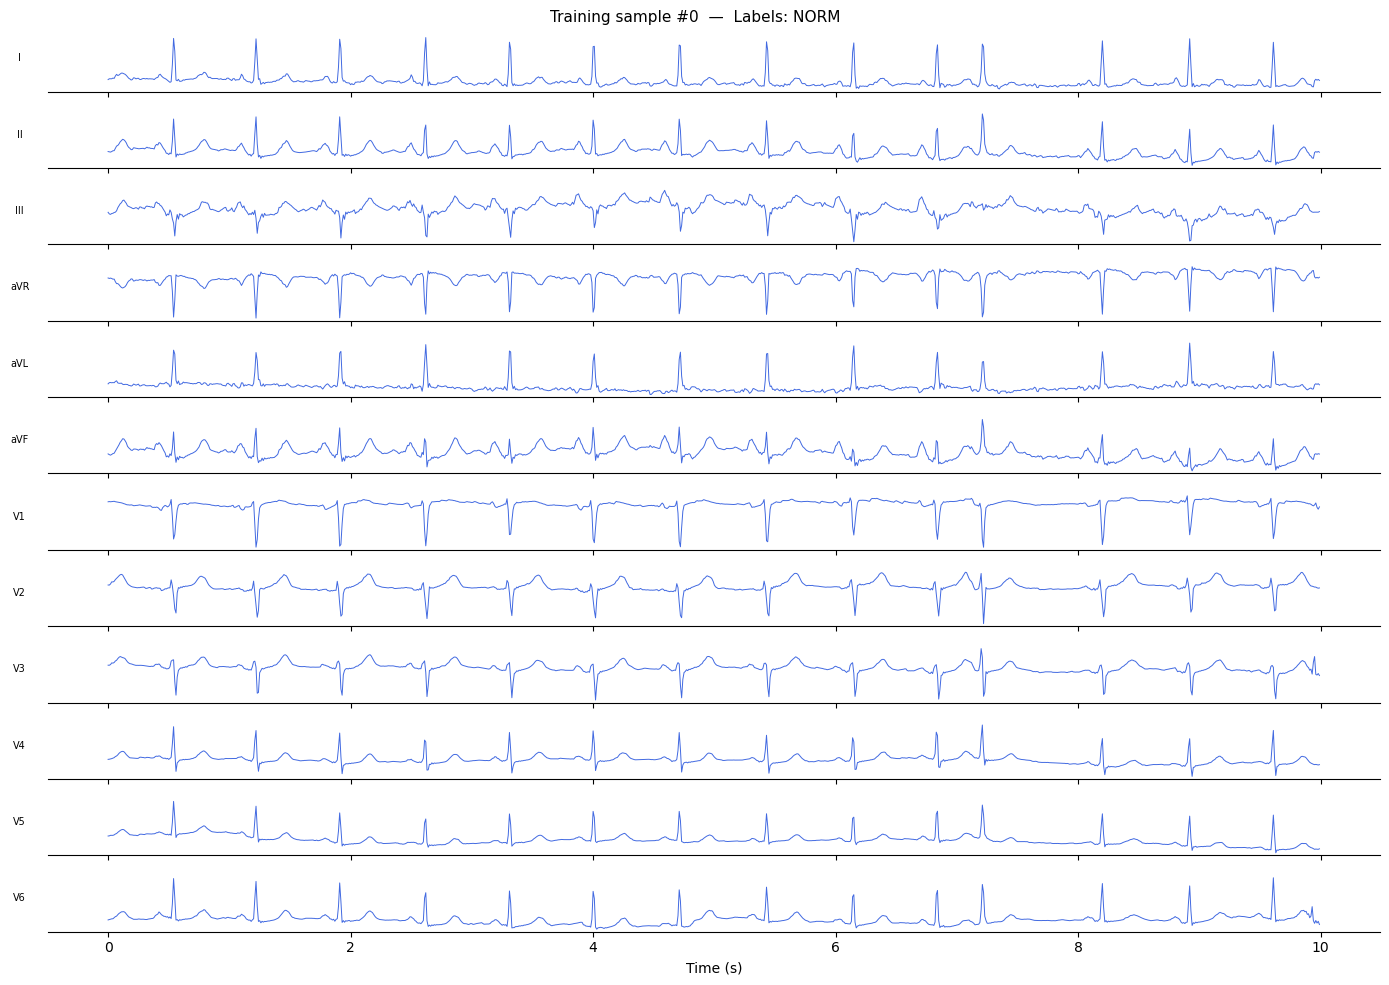

In [9]:
LEAD_NAMES = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']

def plot_ecg(sig_tensor, label_tensor, title='ECG Sample'):
    """sig_tensor: (12, T)"""
    sig = sig_tensor.numpy()                    # (12, T)
    labels = label_tensor.numpy()
    active = [SUPERCLASSES[i] for i, v in enumerate(labels) if v == 1]

    fig, axes = plt.subplots(12, 1, figsize=(14, 10), sharex=True)
    t = np.arange(sig.shape[1]) / SAMPLING_RATE
    for i, ax in enumerate(axes):
        ax.plot(t, sig[i], lw=0.7, color='royalblue')
        ax.set_ylabel(LEAD_NAMES[i], fontsize=7, rotation=0, labelpad=20)
        ax.set_yticks([])
        ax.spines[['top','right','left']].set_visible(False)
    axes[-1].set_xlabel('Time (s)')
    fig.suptitle(f'{title}  —  Labels: {", ".join(active)}', fontsize=11)
    plt.tight_layout()
    plt.show()

plot_ecg(sig_b[0], lbl_b[0], title='Training sample #0')

## 6 — 1-D CNN Architecture

The network is inspired by the architecture from [Ribeiro et al. (2020)](https://doi.org/10.1038/s41467-020-15432-4):

```
Input  (B, 12, T)
  │
  ├─ Conv1d(12→64, k=15, s=2) → BN → ReLU → MaxPool(2)
  ├─ [ResBlock(64→128, k=11)]×2
  ├─ [ResBlock(128→196, k=9)]×2
  ├─ [ResBlock(196→256, k=7)]×2
  ├─ [ResBlock(256→320, k=5)]×2
  ├─ AdaptiveAvgPool → Flatten
  └─ FC(320→N_CLASSES)  [sigmoid at inference]
```

In [10]:
class ResBlock1D(nn.Module):
    """Pre-activation residual block for 1-D sequences."""

    def __init__(self, in_ch, out_ch, kernel_size=7, stride=1,
                 downsample=True, dropout=0.2):
        super().__init__()
        pad = kernel_size // 2

        self.bn1   = nn.BatchNorm1d(in_ch)
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size,
                               stride=stride, padding=pad, bias=False)
        self.bn2   = nn.BatchNorm1d(out_ch)
        self.drop  = nn.Dropout(dropout)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size,
                               stride=1, padding=pad, bias=False)

        # Skip connection
        if in_ch != out_ch or stride != 1:
            self.skip = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm1d(out_ch)
            )
        else:
            self.skip = nn.Identity()

    def forward(self, x):
        identity = self.skip(x)
        out = F.relu(self.bn1(x))
        out = self.conv1(out)
        out = self.drop(F.relu(self.bn2(out)))
        out = self.conv2(out)
        return out + identity


class ECG1DCNN(nn.Module):
    """Multi-label 1-D CNN for 12-lead ECG classification."""

    def __init__(self, n_leads=12, n_classes=5, dropout=0.2):
        super().__init__()

        # ── Stem ──────────────────────────────────────────────────────────
        self.stem = nn.Sequential(
            nn.Conv1d(n_leads, 64, kernel_size=15, stride=2,
                      padding=7, bias=False),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1),
        )                          # (B, 64, T//4)

        # ── Residual stages ───────────────────────────────────────────────
        self.stage1 = self._make_stage(64,  128, kernel_size=11,
                                       n_blocks=2, dropout=dropout)
        self.stage2 = self._make_stage(128, 196, kernel_size=9,
                                       n_blocks=2, dropout=dropout)
        self.stage3 = self._make_stage(196, 256, kernel_size=7,
                                       n_blocks=2, dropout=dropout)
        self.stage4 = self._make_stage(256, 320, kernel_size=5,
                                       n_blocks=2, dropout=dropout)

        # ── Head ──────────────────────────────────────────────────────────
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(320, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, n_classes),
        )

    @staticmethod
    def _make_stage(in_ch, out_ch, kernel_size, n_blocks, dropout):
        layers = [ResBlock1D(in_ch, out_ch, kernel_size,
                             stride=2, dropout=dropout)]
        for _ in range(n_blocks - 1):
            layers.append(ResBlock1D(out_ch, out_ch, kernel_size,
                                     stride=1, dropout=dropout))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.pool(x)
        return self.classifier(x)     # logits, shape (B, N_CLASSES)


model = ECG1DCNN(n_leads=N_LEADS, n_classes=N_CLASSES, dropout=0.2).to(DEVICE)

# ── Parameter count ───────────────────────────────────────────────────────
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {n_params:,}')

# Quick forward-pass sanity check
with torch.no_grad():
    dummy = torch.randn(2, N_LEADS, SEQ_LEN).to(DEVICE)
    out   = model(dummy)
    print(f'Output shape: {out.shape}  (expected (2, {N_CLASSES}))')

Trainable parameters: 5,794,141
Output shape: torch.Size([2, 5])  (expected (2, 5))


## 7 — Loss, Optimiser & Scheduler

In [11]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimiser = torch.optim.AdamW(model.parameters(), lr=LR,
                               weight_decay=WEIGHT_DECAY)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimiser,
    max_lr=LR,
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS,
    pct_start=0.1,
    anneal_strategy='cos'
)

scaler_amp = GradScaler(enabled=(DEVICE.type == 'cuda'))

## 8 — Training & Validation Loop

In [13]:
def run_epoch(loader, model, criterion, optimiser=None, scaler_amp=None,
              scheduler=None, desc='train'):
    """One epoch of training or evaluation.

    Returns
    -------
    avg_loss : float
    all_logits : np.ndarray  (N, C)
    all_labels : np.ndarray  (N, C)
    """
    training = optimiser is not None
    model.train(training)

    total_loss = 0.0
    all_logits, all_labels = [], []

    pbar = tqdm(loader, desc=desc, leave=False)
    for sigs, labels in pbar:
        sigs   = sigs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        with autocast(enabled=(DEVICE.type == 'cuda')):
            logits = model(sigs)
            loss   = criterion(logits, labels)

        if training:
            optimiser.zero_grad()
            scaler_amp.scale(loss).backward()
            scaler_amp.unscale_(optimiser)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler_amp.step(optimiser)
            scaler_amp.update()
            if scheduler is not None:
                scheduler.step()

        total_loss += loss.item() * sigs.size(0)
        all_logits.append(logits.detach().cpu().numpy())
        all_labels.append(labels.detach().cpu().numpy())
        pbar.set_postfix(loss=f'{loss.item():.4f}')

    avg_loss   = total_loss / len(loader.dataset)
    all_logits = np.concatenate(all_logits, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    return avg_loss, all_logits, all_labels


def macro_auc(logits, labels):
    probs = 1 / (1 + np.exp(-logits))    # sigmoid
    return roc_auc_score(labels, probs, average='macro')

In [14]:
history = dict(train_loss=[], val_loss=[], train_auc=[], val_auc=[])
best_val_auc = 0.0
patience_ctr = 0

for epoch in range(1, EPOCHS + 1):
    # ── Train ──────────────────────────────────────────────────────────────
    tr_loss, tr_logits, tr_labels = run_epoch(
        train_loader, model, criterion, optimiser,
        scaler_amp, scheduler, desc=f'[{epoch:02d}/{EPOCHS}] train'
    )

    # ── Validate ───────────────────────────────────────────────────────────
    with torch.no_grad():
        vl_loss, vl_logits, vl_labels = run_epoch(
            val_loader, model, criterion, desc=f'[{epoch:02d}/{EPOCHS}] val '
        )

    tr_auc = macro_auc(tr_logits, tr_labels)
    vl_auc = macro_auc(vl_logits, vl_labels)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_auc'].append(tr_auc)
    history['val_auc'].append(vl_auc)

    print(f'Epoch {epoch:02d}  '
          f'Train loss {tr_loss:.4f} AUC {tr_auc:.4f}  |  '
          f'Val loss {vl_loss:.4f} AUC {vl_auc:.4f}')

    # ── Checkpoint & early stopping ────────────────────────────────────────
    if vl_auc > best_val_auc:
        best_val_auc = vl_auc
        torch.save(model.state_dict(), CKPT_PATH)
        print(f'  ✓ New best val AUC: {best_val_auc:.4f} — checkpoint saved.')
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f'Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs).')
            break

print(f'\nTraining complete.  Best val AUC: {best_val_auc:.4f}')

KeyboardInterrupt: 

## 9 — Training Curves

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ep = range(1, len(history['train_loss']) + 1)

ax1.plot(ep, history['train_loss'], label='Train', marker='.')
ax1.plot(ep, history['val_loss'],   label='Val',   marker='.')
ax1.set(xlabel='Epoch', ylabel='BCE Loss', title='Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ep, history['train_auc'], label='Train', marker='.')
ax2.plot(ep, history['val_auc'],   label='Val',   marker='.')
ax2.set(xlabel='Epoch', ylabel='Macro AUC-ROC', title='AUC-ROC', ylim=(0.5, 1.0))
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 10 — Evaluation on the Test Set

In [ ]:
# Restore best checkpoint
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

with torch.no_grad():
    _, test_logits, test_labels = run_epoch(
        test_loader, model, criterion, desc='test'
    )

test_probs = 1 / (1 + np.exp(-test_logits))    # sigmoid

# ── Per-class AUC ──────────────────────────────────────────────────────────
print('=== Per-class AUC-ROC ===')
auc_per_class = roc_auc_score(test_labels, test_probs, average=None)
for sc, auc in zip(SUPERCLASSES, auc_per_class):
    print(f'  {sc:6s}: {auc:.4f}')
print(f'  {"MACRO":6s}: {auc_per_class.mean():.4f}')

# ── Per-class Average Precision ────────────────────────────────────────────
print('\n=== Per-class Average Precision (AP) ===')
ap_per_class = average_precision_score(test_labels, test_probs, average=None)
for sc, ap in zip(SUPERCLASSES, ap_per_class):
    print(f'  {sc:6s}: {ap:.4f}')
print(f'  {"MACRO":6s}: {ap_per_class.mean():.4f}')

In [ ]:
# ── Optimal threshold selection (via val set) ──────────────────────────────
model.eval()
with torch.no_grad():
    _, val_logits, val_labels = run_epoch(
        val_loader, model, criterion, desc='val-thresh'
    )
val_probs = 1 / (1 + np.exp(-val_logits))

thresholds = np.arange(0.1, 0.9, 0.02)
best_thresh = np.zeros(N_CLASSES)

for c in range(N_CLASSES):
    best_f1, best_t = 0.0, 0.5
    for t in thresholds:
        preds = (val_probs[:, c] >= t).astype(int)
        f1    = f1_score(val_labels[:, c], preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t  = t
    best_thresh[c] = best_t

print('Optimal thresholds per class (from val set):')
for sc, t in zip(SUPERCLASSES, best_thresh):
    print(f'  {sc}: {t:.2f}')

In [ ]:
# ── Classification report ──────────────────────────────────────────────────
test_preds = (test_probs >= best_thresh).astype(int)

print('=== Classification Report (test set) ===')
print(classification_report(test_labels, test_preds,
                             target_names=SUPERCLASSES, digits=4))

### 10.1 — Per-class Confusion Matrices

In [ ]:
cms = multilabel_confusion_matrix(test_labels, test_preds)

fig, axes = plt.subplots(1, N_CLASSES, figsize=(14, 3))
for i, (ax, sc) in enumerate(zip(axes, SUPERCLASSES)):
    cm = cms[i]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred 0','Pred 1'],
                yticklabels=['True 0','True 1'],
                cbar=False)
    ax.set_title(sc)

plt.suptitle('Per-class Confusion Matrices (test set)', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

### 10.2 — ROC Curves

In [ ]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(7, 6))
colors = plt.cm.tab10(np.linspace(0, 0.5, N_CLASSES))

for i, (sc, col) in enumerate(zip(SUPERCLASSES, colors)):
    fpr, tpr, _ = roc_curve(test_labels[:, i], test_probs[:, i])
    auc = auc_per_class[i]
    ax.plot(fpr, tpr, lw=1.5, color=col, label=f'{sc} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
ax.set(xlabel='FPR', ylabel='TPR', title='ROC Curves — Test Set')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 11 — Inference Helper

In [ ]:
@torch.no_grad()
def predict(wfdb_path: str,
            model: nn.Module,
            thresholds: np.ndarray,
            sampling_rate: int = 100,
            device=DEVICE) -> dict:
    """Classify a single WFDB record.

    Parameters
    ----------
    wfdb_path     : path without extension, e.g. '/data/ptbxl/records100/00000/00001_lr'
    model         : trained ECG1DCNN (eval mode)
    thresholds    : per-class decision thresholds (length N_CLASSES)
    sampling_rate : 100 or 500

    Returns
    -------
    dict with keys 'probabilities', 'predictions', 'labels'
    """
    sig, _ = wfdb.rdsamp(wfdb_path)
    sig = sig.astype(np.float32)
    sig = (sig - sig.mean(0)) / (sig.std(0) + 1e-8)    # per-sample normalise
    sig = torch.tensor(sig.T, dtype=torch.float32).unsqueeze(0).to(device)  # (1, 12, T)

    model.eval()
    logits = model(sig).cpu().numpy()[0]                # (N_CLASSES,)
    probs  = 1 / (1 + np.exp(-logits))
    preds  = (probs >= thresholds).astype(int)

    return {
        'probabilities': dict(zip(SUPERCLASSES, probs.tolist())),
        'predictions'  : dict(zip(SUPERCLASSES, preds.tolist())),
        'labels'       : [sc for sc, p in zip(SUPERCLASSES, preds) if p]
    }


# Example usage:
# result = predict('/path/to/ptbxl/records100/00000/00001_lr', model, best_thresh)
# print(result)

## 12 — Saving & Loading the Model

In [ ]:
# Save full model bundle (weights + thresholds + class names)
bundle = {
    'state_dict'  : model.state_dict(),
    'thresholds'  : best_thresh,
    'superclasses': SUPERCLASSES,
    'n_leads'     : N_LEADS,
    'n_classes'   : N_CLASSES,
    'sampling_rate': SAMPLING_RATE,
}
torch.save(bundle, 'ecg_1dcnn_bundle.pt')
print('Bundle saved.')

# To reload:
# bundle = torch.load('ecg_1dcnn_bundle.pt', map_location='cpu')
# model  = ECG1DCNN(bundle['n_leads'], bundle['n_classes'])
# model.load_state_dict(bundle['state_dict'])
# model.eval()

---

## Notes & Next Steps

| Topic | Options |
|---|---|
| **Signal resolution** | Switch to `records500/` + `filename_hr` for 500 Hz — increase `SEQ_LEN = 5000` |
| **Stronger baseline** | Try SE-Net (channel attention) blocks or a lightweight Transformer encoder on top of CNN features |
| **Label granularity** | Replace superclasses with diagnostic subclasses for finer-grained classification |
| **Metadata fusion** | Concatenate demographic features (age, sex) to the pooled embedding before the classifier head |
| **Graph migration** | Each lead becomes a node; edge weights = cross-lead correlation or known anatomical connectivity → ST-GCN / ST-GNN |
| **Explainability** | Apply Grad-CAM on conv layers to identify discriminative ECG segments per class |